In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV

In [3]:
# Load data
df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Cancer treatment/T47D.csv")

df["Metadata_well"] = df["Metadata_well"].astype(str)

In [4]:
X = df.drop(columns=['phase'])
y = df['phase']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=949, stratify=y)

# Separate features and target
X_0 = df[df["Metadata_well"] == 0].drop(columns=['phase'])
y_0 = df[df["Metadata_well"] == 0]['phase']

# Split data into train and test sets (80:20)
X_train_0, X_test_0, y_train_0, y_test_0 = train_test_split(X_0, y_0, test_size=0.2, random_state=949, stratify=y_0)

# Separate features and target
X_1 = df[df["Metadata_well"] == 1].drop(columns=['phase'])
y_1 = df[df["Metadata_well"] == 1]['phase']

# Split data into train and test sets (80:20)
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.2, random_state=949, stratify=y_1)

# Separate features and target
X_10 = df[df["Metadata_well"] == 10].drop(columns=['phase'])
y_10 = df[df["Metadata_well"] == 10]['phase']

# Split data into train and test sets (80:20)
X_train_10, X_test_10, y_train_10, y_test_10 = train_test_split(X_10, y_10, test_size=0.2, random_state=949, stratify=y_10)

# Separate features and target
X_100 = df[df["Metadata_well"] == 100].drop(columns=['phase'])
y_100 = df[df["Metadata_well"] == 100]['phase']

# Split data into train and test sets (80:20)
X_train_100, X_test_100, y_train_100, y_test_100 = train_test_split(X_100, y_100, test_size=0.2, random_state=949, stratify=y_100)

# Separate features and target
X_1000 = df[df["Metadata_well"] == 1000].drop(columns=['phase'])
y_1000 = df[df["Metadata_well"] == 1000]['phase']

# Split data into train and test sets (80:20)
X_train_1000, X_test_1000, y_train_1000, y_test_1000 = train_test_split(X_1000, y_1000, test_size=0.2, random_state=949, stratify=y_1000)

ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [5]:
X_well = df.drop(columns=['Metadata_well', 'phase'])
y_well = df['Metadata_well']

X_train_well, X_test_well, y_train_well, y_test_well = train_test_split(X_well, y_well, test_size=0.2, random_state=949, stratify=y_well)

In [6]:
# retrain model
rf = RandomForestClassifier(n_estimators=500, max_depth=50, max_features=15, random_state=949)
rf.fit(X_train_well, y_train_well)

# Predict on training and test sets
y_train_pred = rf.predict(X_train_well)
y_test_pred = rf.predict(X_test_well)

KeyboardInterrupt: 

In [67]:
print("=== Training Set ===")
print("Overall Accuracy:", accuracy_score(y_train_well, y_train_pred))

print("\n=== Test Set ===")
print("Overall Accuracy:", accuracy_score(y_test_well, y_test_pred))

=== Training Set ===
Overall Accuracy: 1.0

=== Test Set ===
Overall Accuracy: 0.7340516239051237


In [24]:
## hypertuning

rf = RandomForestClassifier(n_estimators=500, max_depth=50, max_features='sqrt', random_state=949)

param_grid = {
    'n_estimators': [600, 700],      
}

# Set up GridSearch with 10-fold cross-validation optimizing for accuracy
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=10,
    scoring='accuracy',
    n_jobs=1
)

# Fit the model to your data
grid_search.fit(X_train_well, y_train_well)

#Output best settings and best accuracy
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

Best parameters: {'n_estimators': 600}
Best cross-validation accuracy: 0.7316912435093854


In [ ]:
# OOB error 
# Define the values of max_features to test
max_features_options = [5,10,15,20]  # Try 3–5 reasonable values

oob_results = {}

# Loop over different max_features
for mf in max_features_options:
    rf = RandomForestClassifier(
        n_estimators=600,
        max_depth=50,
        max_features=mf,
        oob_score=True,
        bootstrap=True,
        random_state=949,
        n_jobs=-1
    )
    rf.fit(X_train_well, y_train_well)
    oob_results[mf] = rf.oob_score_

# Show OOB results
print("=== OOB Scores by max_features ===")
for mf, score in oob_results.items():
    print(f"max_features={mf}: OOB Accuracy = {score:.4f}")

# Choose best setting
best_mf = max(oob_results, key=oob_results.get)
print(f"\nBest max_features based on OOB: {best_mf}")

In [26]:
# OOB error 
# Define the values of max_features to test
max_features_options = [5,10,15,20]  # Try 3–5 reasonable values

oob_results = {}

# Loop over different max_features
for mf in max_features_options:
    rf = RandomForestClassifier(
        n_estimators=600,
        max_depth=50,
        max_features=mf,
        oob_score=True,
        bootstrap=True,
        random_state=949,
        n_jobs=-1
    )
    rf.fit(X_train_well, y_train_well)
    oob_results[mf] = rf.oob_score_

# Show OOB results
print("=== OOB Scores by max_features ===")
for mf, score in oob_results.items():
    print(f"max_features={mf}: OOB Accuracy = {score:.4f}")

# Choose best setting
best_mf = max(oob_results, key=oob_results.get)
print(f"\nBest max_features based on OOB: {best_mf}")

=== OOB Scores by max_features ===
max_features=5: OOB Accuracy = 0.7319
max_features=10: OOB Accuracy = 0.7328
max_features=15: OOB Accuracy = 0.7290
max_features=20: OOB Accuracy = 0.7266

Best max_features based on OOB: 10


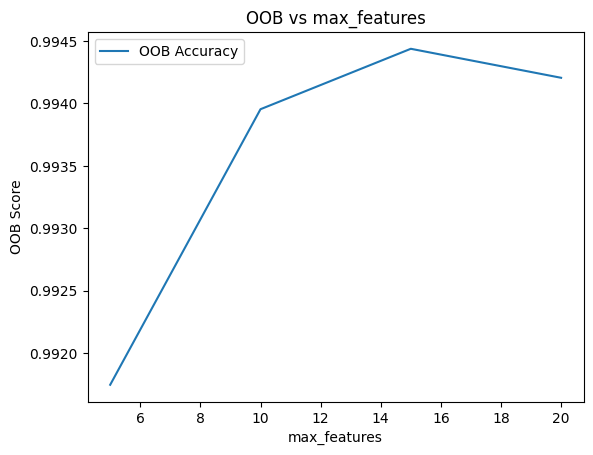

In [52]:
## OOB plot
max_features_range = [5,10,15,20]  # example for 300 features
oob_scores = []

for mf in max_features_range:
    rf = RandomForestClassifier(
        n_estimators=600,
        max_depth=50,
        max_features=mf,
        oob_score=True,
        random_state=42,
        bootstrap=True
    )
    rf.fit(X_train, y_train)
    
    oob_scores.append(rf.oob_score_)

plt.plot(max_features_range, oob_scores, label="OOB Accuracy")
plt.xlabel("max_features")
plt.ylabel("OOB Score")
plt.title("OOB vs max_features")
plt.legend()
plt.show()

In [7]:
# retrain model
rf = RandomForestClassifier(n_estimators=600, max_depth=50, max_features=10, random_state=949, n_jobs=-1)
rf.fit(X_train_well, y_train_well)

# Predict on training and test sets
y_train_pred = rf.predict(X_train_well)
y_test_pred = rf.predict(X_test_well)

In [69]:
print("=== Training Set ===")
print("Overall Accuracy:", accuracy_score(y_train_well, y_train_pred))

print("\n=== Test Set ===")
print("Overall Accuracy:", accuracy_score(y_test_well, y_test_pred))

=== Training Set ===
Overall Accuracy: 1.0

=== Test Set ===
Overall Accuracy: 0.7361444849236494


In [61]:
print("Test Confusion Matrix")
print(confusion_matrix(y_test_well, y_test_pred, labels = ["0", "1", "10", "100", "1000"]))

Test Confusion Matrix
[[1013  390  445  132  101]
 [ 380 1160  400  144   72]
 [ 202  219 1805  156  148]
 [  35   51   52 2898  164]
 [  20   22   41  236 2615]]


In [74]:
# save results
# === Load existing results ===
results_df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Cancer treatment/cancer_baseline_results.csv", index_col=0)

# === Compute accuracy ===
from sklearn.metrics import accuracy_score

overall_acc = accuracy_score(y_test_well, y_test_pred)

df_test = pd.DataFrame({'true': y_test_well, 'pred': y_test_pred})

# === Insert values ===
model_name = "RF"
results_df.loc[model_name, "Accuracy"] = overall_acc

# === Save updated file ===
results_df.to_csv("/Users/mariahloehr/IICD/IICD/Cancer treatment/cancer_baseline_results.csv")

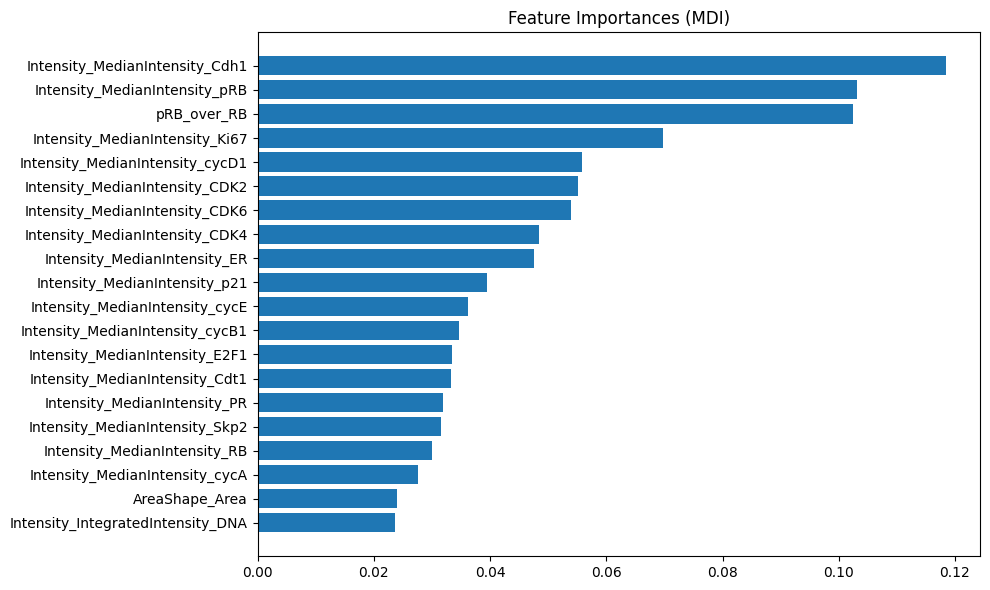

In [16]:
# Get feature importances (MDI)
importances = rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]  # Sort by importance descending

# Select top n indices
top_n = 20
top_indices = indices[:top_n]

# Plot
plt.figure(figsize=(10, 6))
plt.title("Feature Importances (MDI)")
plt.barh(range(top_n), importances[top_indices], align='center')
plt.yticks(range(top_n), feature_names[top_indices])
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
# Extract MDI importances
rf_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
rf_importances_sorted = rf_importances.sort_values(ascending=False)

# Top features
rf_importances_sorted.head(20).plot(kind='barh', figsize=(8, 6), title='Random Forest MDI (Top 20)')

ValueError: Length of values (20) does not match length of index (21)